# Procedures:

## 9.1 Introduction to Matplotlib
Setting up<br>
We started by importing matplotlib.pyplot and pandas. We loaded two datasets: Facebook stock prices for 2018 and earthquake data from a specific time period. This is the usual setup before plotting.

First line plot <br>
We used plt.plot() to draw a line chart of Facebook's opening price over time. We had to call plt.show() to actually see it. The plot showed how the stock price moved up and down throughout the year.

Using %matplotlib inline <br>
Then we learned about the magic command %matplotlib inline. Putting this at the top of the notebook means we don't have to type plt.show() every time – the plot just appears automatically below the code cell. It's super convenient.

Scatter plot with style string <br>
We tried making a scatter plot by passing 'ro' as the style – that stands for red circles. We plotted the high vs low prices for just the first 20 days of Facebook data. The points were all clustered together, which makes sense because high and low prices on the same day are usually close.

Understanding Figure and Axes <br>
We learned that a "Figure" is like the blank canvas, and "Axes" are the actual plots we draw on. One Figure can hold multiple Axes. We created an empty Figure just to see what it looks like.

Creating subplots with plt.subplots() <br>
We made a figure with two side-by-side subplots. On the left we plotted opening price, on the right closing price. This is great for comparing two things without switching between separate graphs.

Picture‑in‑picture with add_axes() <br>
We used add_axes() to put a smaller plot inside a bigger one. The main plot showed opening price, and the inset showed closing price zoomed in. It's like having a magnifying glass for a specific part of the data.

Complex layouts with gridspec <br>
gridspec let us create a more custom layout – a 3×3 grid where one subplot took up two rows, and another stretched across the whole bottom. We plotted different stock columns in each to see them all at once.

Saving plots <br>
We used fig.savefig() to save the last plot as an image file. Handy for including in reports or sharing.

Cleaning up with plt.close() <br>
We closed all open figures with plt.close('all') to free up memory. It's a good habit, especially when you're making lots of plots.

Changing default settings with rcParams <br>
We peeked at the default figure size and changed it using rcParams. Then we reset everything back to normal with rcdefaults(). This showed us we can tweak the global style if we want, though usually we set size per plot.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd

### Plotting Lines

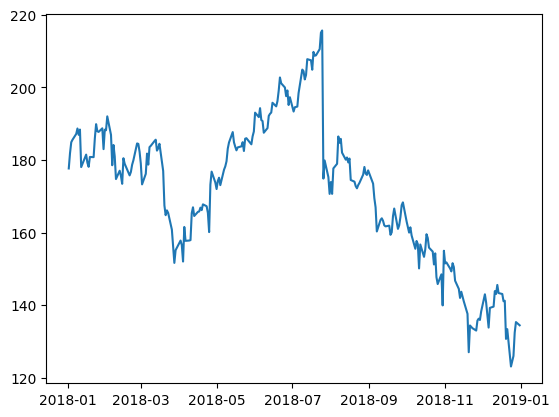

In [5]:
fb = pd.read_csv(
    '/Users/macbookpro/CPE-311/HOA/HOA 9.1/Datasets/fb_stock_prices_2018.csv', index_col='date', parse_dates=True
)
plt.plot(fb.index, fb.open )

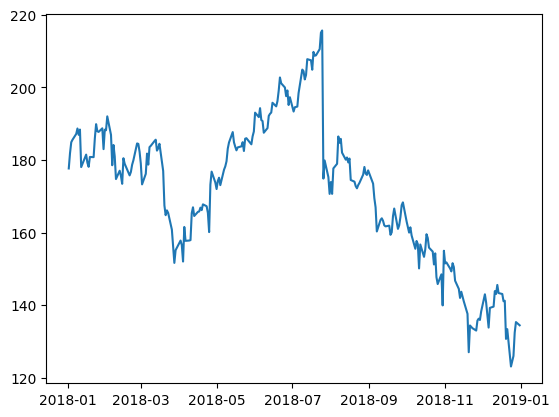

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

fb = pd.read_csv(
    '/Users/macbookpro/CPE-311/HOA/HOA 9.1/Datasets/fb_stock_prices_2018.csv', index_col='date', parse_dates=True
)
plt.plot(fb.index, fb.open)

### Scatter plots

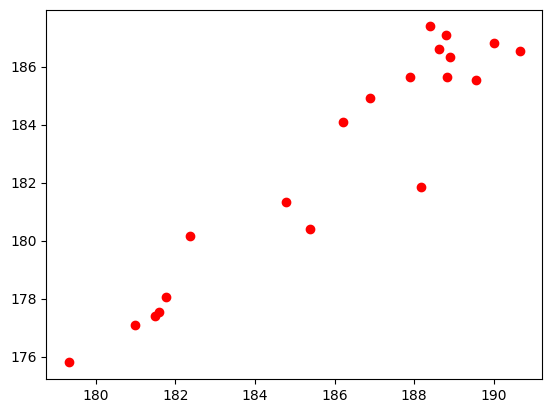

In [8]:
plt.plot('high', 'low', 'ro', data=fb.head(20))

### Histograms

(array([6.400e+01, 4.450e+02, 1.137e+03, 1.853e+03, 2.114e+03, 8.070e+02,
        2.800e+02, 9.200e+01, 9.000e+00, 2.000e+00]),
 array([-1.26 , -0.624,  0.012,  0.648,  1.284,  1.92 ,  2.556,  3.192,
         3.828,  4.464,  5.1  ]),
 <BarContainer object of 10 artists>)

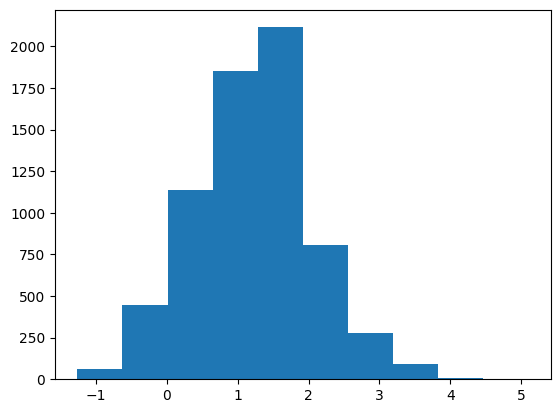

In [10]:
quakes = pd.read_csv('/Users/macbookpro/CPE-311/HOA/HOA 9.1/Datasets/earthquakes-1.csv')
plt.hist(quakes.query('magType == "ml"').mag)

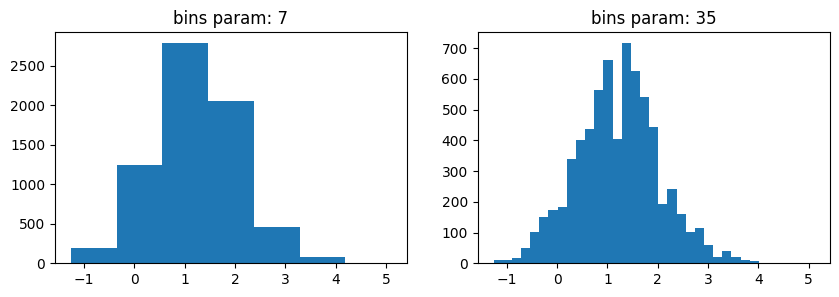

In [12]:
x = quakes.query('magType == "ml"').mag
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, bins in zip(axes, [7, 35]):    
    ax.hist(x, bins=bins)    
    ax.set_title(f'bins param: {bins}')


### Plot Components

#### Figure

In [13]:
fig = plt.figure()

<Figure size 640x480 with 0 Axes>

### Creating subplots


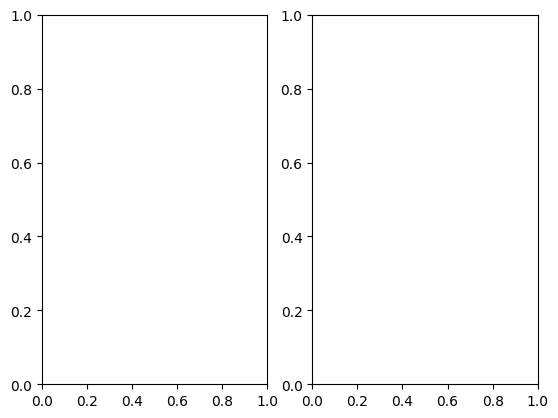

In [14]:
fig, axes = plt.subplots(1,2)

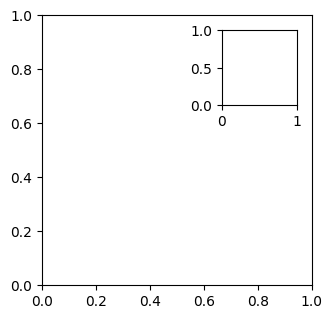

In [15]:
fig = plt.figure(figsize=(3, 3))
outside = fig.add_axes([0.1, 0.1, 0.9, 0.9])
inside = fig.add_axes([0.7, 0.7, 0.25, 0.25])


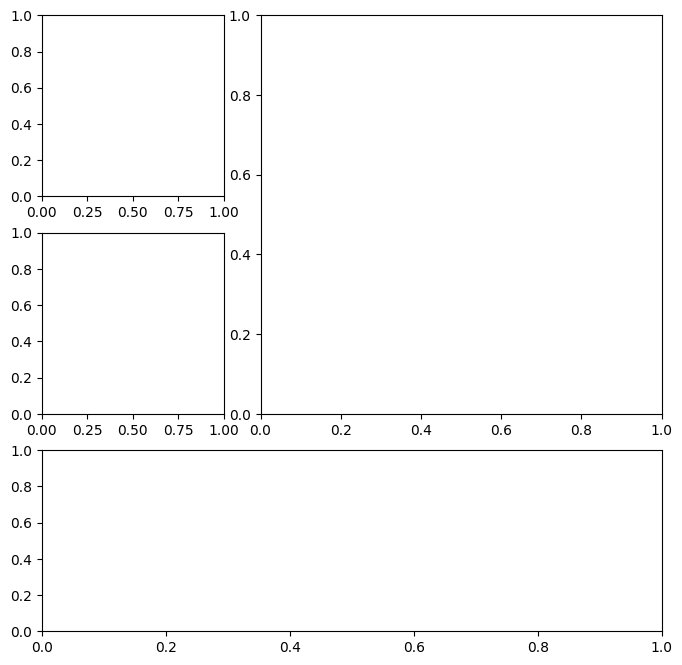

In [17]:
fig = plt.figure(figsize=(8, 8))
gs = fig.add_gridspec(3, 3)
top_left = fig.add_subplot(gs[0, 0])
mid_left = fig.add_subplot(gs[1, 0])
top_right = fig.add_subplot(gs[:2, 1:])
bottom = fig.add_subplot(gs[2,:])


In [18]:
fig.savefig('empty.png')

In [19]:
plt.close('all')

In [20]:
fig = plt.figure(figsize=(10, 4))

<Figure size 1000x400 with 0 Axes>

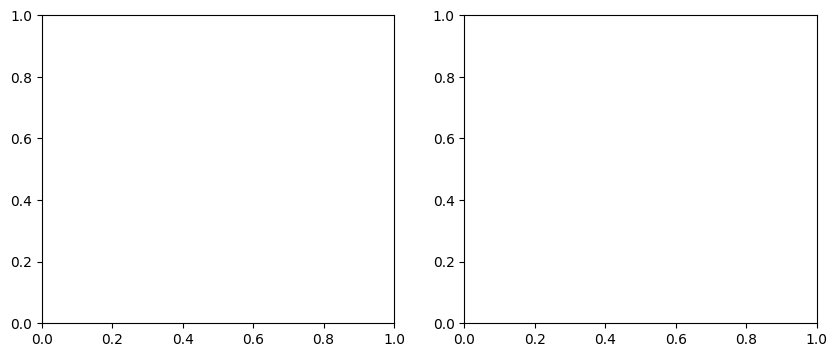

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

In [22]:
import random
import matplotlib as mpl    

rcparams_list = list(mpl.rcParams.keys())
random.seed(20)
random.shuffle(rcparams_list)
sorted(rcparams_list[:20])

['axes.edgecolor',
 'axes.titleweight',
 'boxplot.whiskerprops.linestyle',
 'date.autoformatter.day',
 'figure.constrained_layout.hspace',
 'figure.titlesize',
 'image.interpolation_stage',
 'keymap.copy',
 'legend.framealpha',
 'legend.handleheight',
 'lines.dash_joinstyle',
 'lines.markerfacecolor',
 'mathtext.default',
 'mathtext.fallback',
 'pdf.compression',
 'svg.fonttype',
 'text.usetex',
 'yaxis.labellocation',
 'ytick.major.size',
 'ytick.minor.visible']

In [23]:
mpl.rcParams['figure.figsize']

[6.4, 4.8]

In [24]:
mpl.rcParams['figure.figsize'] = (300, 10)
mpl.rcParams['figure.figsize']

[300.0, 10.0]

In [26]:
mpl.rcdefaults()
mpl.rcParams['figure.figsize']

[6.4, 4.8]

In [28]:
plt.rc('figure', figsize=(20, 20))
plt.rcdefaults()

## 9.2 Plotting with Pandas
Basic line plot with pandas<br>
We used the DataFrame's .plot() method to make the same line plot of opening price. It's much simpler – just one line of code. We added a title and removed the legend because it wasn't needed.

Plotting multiple lines<br>
By giving a list of column names, we plotted open, high, low, and close all on the same graph. We used different line styles to tell them apart. It was interesting to see how they move together.

Subplots automatically with pandas<br>
Passing subplots=True to .plot() made pandas create separate little plots for each numeric column, arranged in a grid. We set the layout to 3 rows and 2 columns. This is a quick way to get an overview of all your variables.

Scatter plot<br>
We created a new column max_abs_change (high minus low) and made a scatter plot of that against volume. There didn't seem to be a clear pattern – the points were all over the place.

Scatter plot with log scale<br>
Because volume values are huge compared to price changes, we added logx=True to use a logarithmic scale on the x‑axis. That spread the points out a bit and made it easier to see what's going on.

Adding transparency with alpha<br>
We set alpha=0.25 to make the points semi‑transparent. This helped see where lots of points overlapped – darker areas meant more data.

Hexbin plot<br>
Hexbin plots are another way to handle overplotting. The plot is divided into hexagons, and the color tells you how many points fall in each hexagon. We used a gray colormap and adjusted gridsize to control the number of hexagons.

Correlation heatmap<br>
Pandas doesn't have a built‑in heatmap, but we used matshow() from matplotlib to show the correlation matrix of the stock data. The colors ranged from red (positive correlation) to blue (negative). Not surprisingly, open, high, low, and close were all highly correlated.

Histogram of volume<br>
We made a histogram of trading volume. It was skewed to the right – most days had lower volume, with a few days of very high volume.

Overlapping histograms for earthquake magTypes<br>
We looped through each unique magnitude type in the earthquake data and plotted a histogram for each, using alpha to make them see‑through. This let us compare the distributions of different magnitude scales.

Kernel Density Estimation (KDE)<br>
KDE gives a smooth curve of the distribution. We plotted the KDE of Facebook's high price – it showed a peak around 180‑200 dollars.

Histogram + KDE together<br>
We put a histogram and a KDE on the same plot. The histogram gave the raw counts, and the KDE smoothed it out. Good for understanding the shape of the data.

ECDF (Empirical Cumulative Distribution Function)<br>
Using statsmodels, we plotted the ECDF of earthquake magnitudes for the 'ml' type. The line shows the proportion of earthquakes with magnitude less than or equal to a given value. We saw that about 98% of 'ml' earthquakes had magnitude 3 or less.

Box plot of OHLC<br>
A box plot of open, high, low, and close showed the median, quartiles, and outliers. All four had similar medians, but we could see the spread.

Grouped box plots by volume<br>
We split volume into three bins (low, med, high) and made box plots of the price columns for each bin. This helped us see if prices behave differently on high‑volume days.

Bar chart of monthly volume<br>
We resampled the data by month and summed the volume, then made a bar chart. Some months had noticeably higher trading volume.

Horizontal bar chart of top earthquake places<br>
We took the top 15 places with the most earthquakes and plotted them as horizontal bars. California and Alaska were at the top. Horizontal bars are great when the category names are long.

Stacked bar chart<br>
We created a pivot table of magnitude bins vs. magType and made a stacked bar chart. Each bar showed the total earthquakes for that magnitude, split by magType.

Normalized stacked bar<br>
We divided each row by its total so that all bars added up to 1 (100%). This made it easier to compare the proportion of each magType across different magnitude ranges.

In [31]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fb = pd.read_csv(
    '/Users/macbookpro/CPE-311/HOA/HOA 9.1/Datasets/fb_stock_prices_2018.csv', index_col='date', parse_dates=True
)
quakes = pd.read_csv('/Users/macbookpro/CPE-311/HOA/HOA 9.1/Datasets/earthquakes-1.csv')

<Axes: title={'center': 'Evolution of Facebook Open Price'}, xlabel='date'>

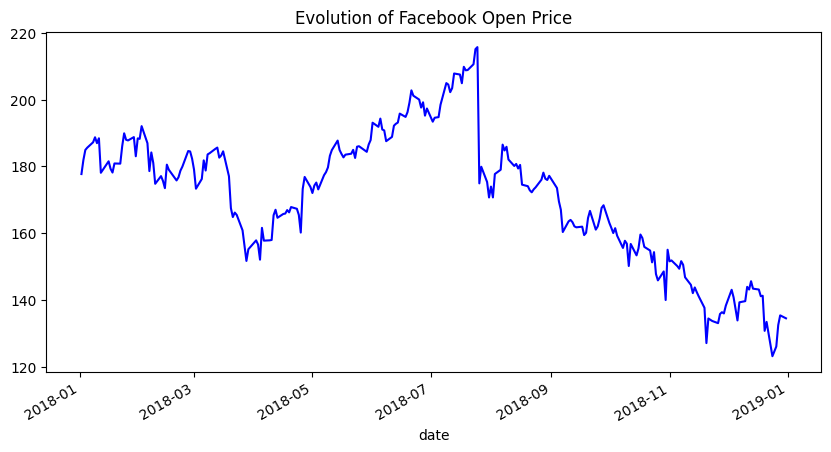

In [32]:
fb.plot(
    kind='line',
    y = 'open',
    figsize = (10, 5),
    style = 'b-',
    legend=False,
    title='Evolution of Facebook Open Price'
)

<Axes: title={'center': 'Evolution of Facebook Open Price'}, xlabel='date'>

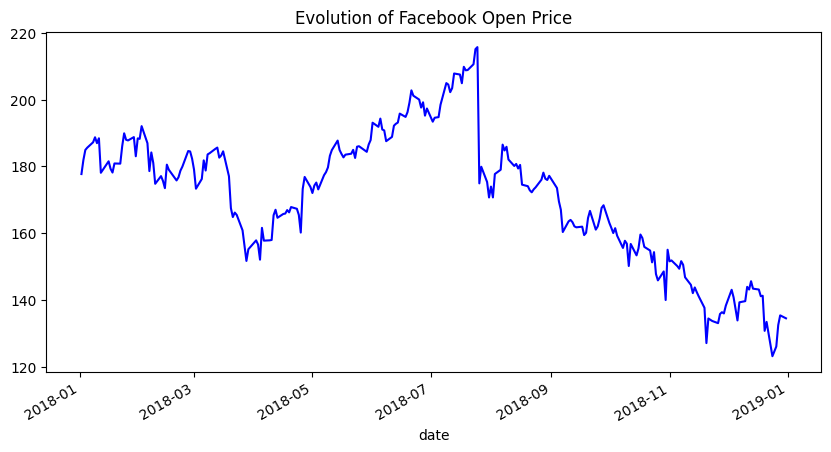

In [33]:
fb.plot(
    kind='line',
    y = 'open',
    figsize = (10, 5),
    color = 'blue',
    linestyle = 'solid',
    legend=False,
    title='Evolution of Facebook Open Price'
)

<Axes: title={'center': 'Facebook OHLC Prices during 1st Week of Trading 2018'}, xlabel='date'>

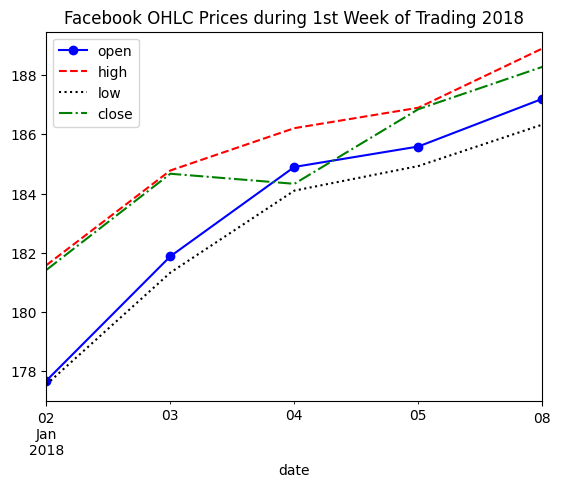

In [34]:
fb.iloc[:5,].plot(
    y=['open', 'high', 'low', 'close'],
    style=['b-o', 'r--', 'k:', 'g-.'],    
    title='Facebook OHLC Prices during 1st Week of Trading 2018'
)


array([[<Axes: xlabel='date'>, <Axes: xlabel='date'>],
       [<Axes: xlabel='date'>, <Axes: xlabel='date'>],
       [<Axes: xlabel='date'>, <Axes: xlabel='date'>]], dtype=object)

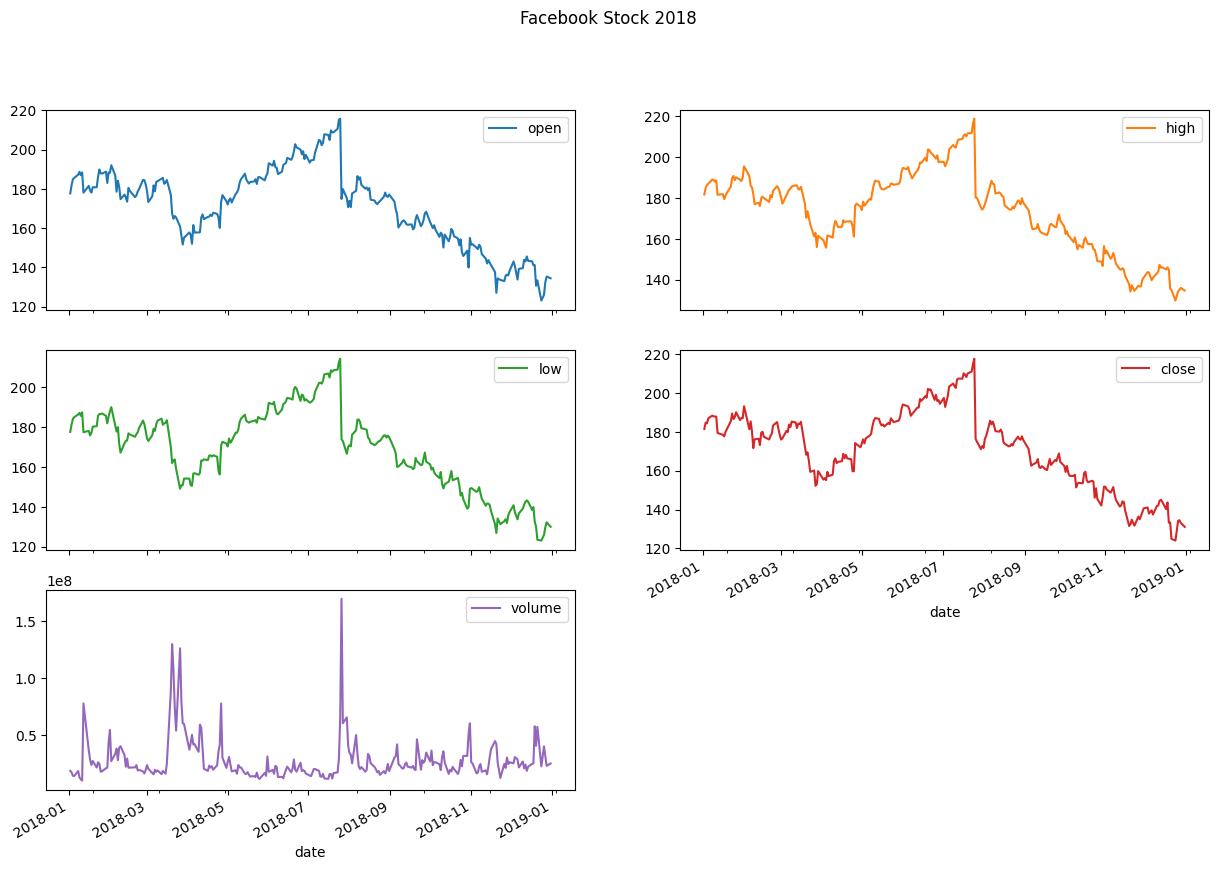

In [35]:
fb.plot(
    kind='line',    
    subplots=True,    
    layout=(3,2),   
    figsize=(15,10),    
    title='Facebook Stock 2018')


<Axes: title={'center': 'Facebook Daily High -Low vs. Volume Traded'}, xlabel='volume', ylabel='max_abs_change'>

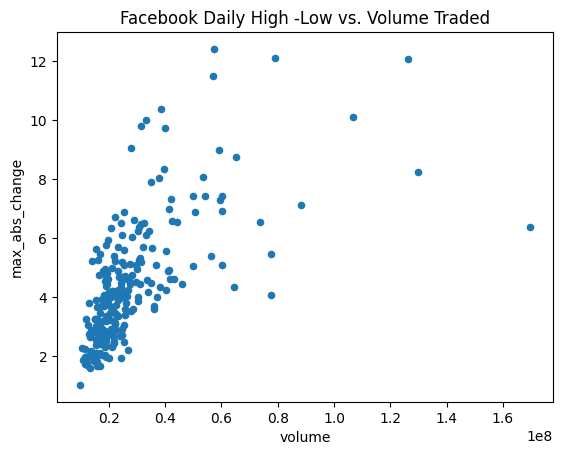

In [36]:
fb.assign(
    max_abs_change=fb.high - fb.low
).plot(
    kind='scatter', x='volume', y='max_abs_change',
    title='Facebook Daily High -Low vs. Volume Traded'
)

<Axes: title={'center': 'Facebook Daily High - Low vs. log(Volume Traded)'}, xlabel='volume', ylabel='max_abs_change'>

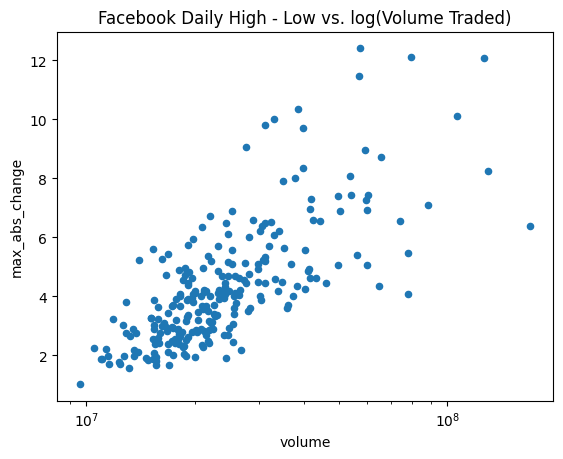

In [37]:
fb.assign(
    max_abs_change=fb.high - fb.low
).plot(
    kind='scatter', x='volume', y='max_abs_change',    
    title='Facebook Daily High - Low vs. log(Volume Traded)',     
    logx=True
)


<Axes: title={'center': 'Facebook Daily High - Low vs. log(Volume Traded)'}, xlabel='volume', ylabel='max_abs_change'>

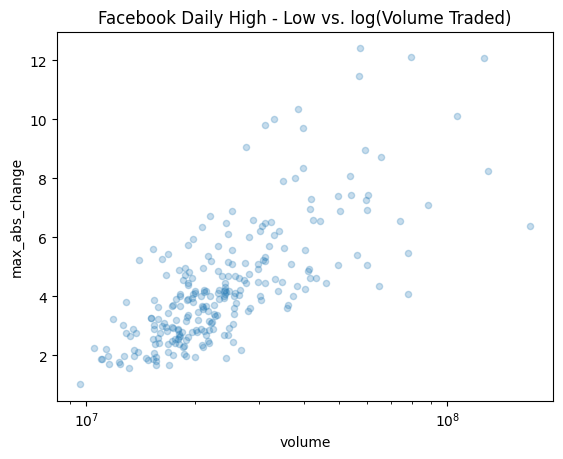

In [38]:
fb.assign(
    max_abs_change=fb.high - fb.low
).plot(
    kind='scatter', x='volume', y='max_abs_change',    
    title='Facebook Daily High - Low vs. log(Volume Traded)',     
    logx=True, alpha=0.25
)

<Axes: title={'center': 'Facebook Daily High - Low vs. log(Volume Traded)'}, xlabel='log_volume', ylabel='max_abs_change'>

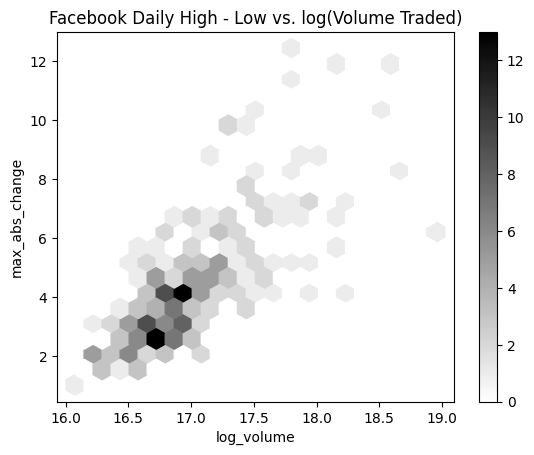

In [39]:
fb.assign(
    log_volume=np.log(fb.volume),    
    max_abs_change=fb.high - fb.low
).plot(    
       kind='hexbin',    
       x='log_volume',    
       y='max_abs_change',    
       title='Facebook Daily High - Low vs. log(Volume Traded)',    
       colormap='gray_r',    
       gridsize=20,     
       sharex=False 
)

/var/folders/q7/1g4_b9fn3pd7z_qq7345v6vr0000gn/T/ipykernel_3663/1813625368.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + labels, rotation=45)
/var/folders/q7/1g4_b9fn3pd7z_qq7345v6vr0000gn/T/ipykernel_3663/1813625368.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + labels)


[Text(0, -1.0, ''),
 Text(0, 0.0, 'open'),
 Text(0, 1.0, 'high'),
 Text(0, 2.0, 'low'),
 Text(0, 3.0, 'close'),
 Text(0, 4.0, 'volume'),
 Text(0, 5.0, 'log_volume'),
 Text(0, 6.0, 'max_abs_change'),
 Text(0, 7.0, '')]

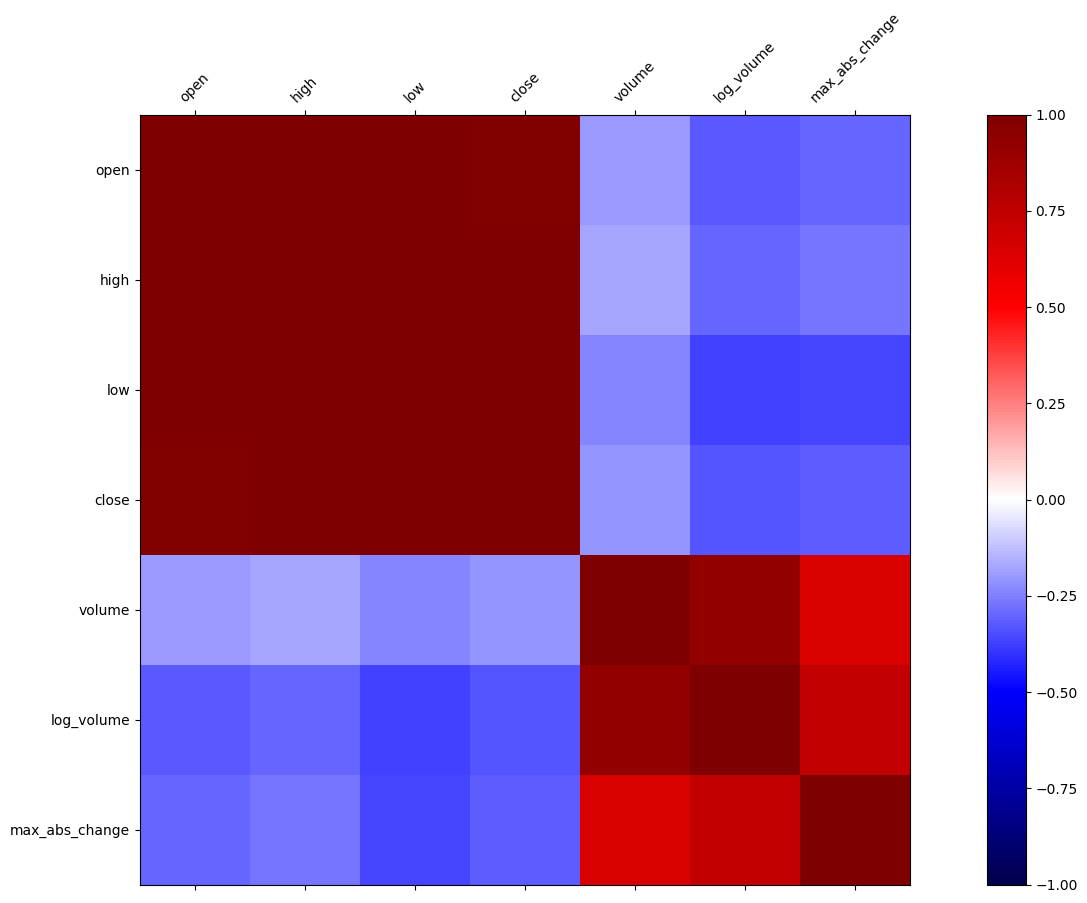

In [46]:
fig, ax = plt.subplots(figsize=(20, 10))

fb_corr = fb.assign(
    log_volume=np.log(fb.volume),
    max_abs_change=fb.high - fb.low
).corr()

im = ax.matshow(fb_corr, cmap='seismic', clim=(-1, 1))
fig.colorbar(im)

labels = [col.lower() for col in fb_corr.columns]
ax.set_xticklabels([''] + labels, rotation=45)
ax.set_yticklabels([''] + labels)

In [47]:
fb_corr.loc['max_abs_change', ['volume', 'log_volume']]

volume        0.642027
log_volume    0.731542
Name: max_abs_change, dtype: float64

Text(0.5, 0, 'Volume traded')

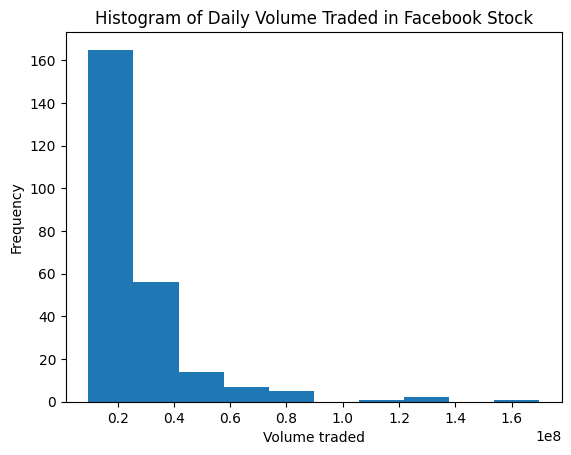

In [48]:
fb.volume.plot(
    kind='hist',
    title='Histogram of Daily Volume Traded in Facebook Stock'
)
plt.xlabel('Volume traded')

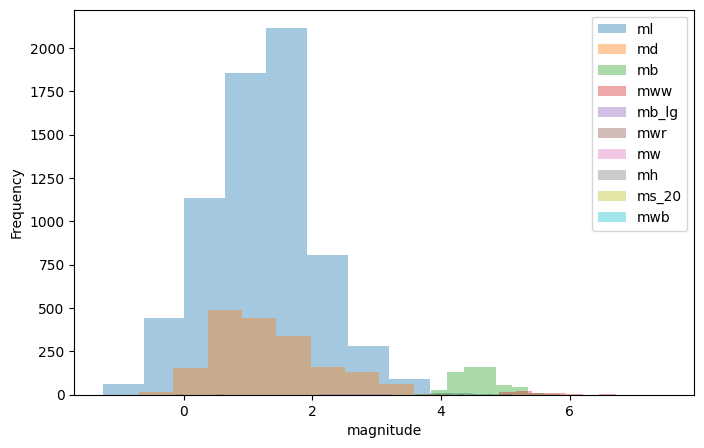

In [49]:
fig, axes = plt.subplots(figsize=(8, 5))
for magtype in quakes.magType.unique():
    data = quakes.query(f'magType == "{magtype}"').mag
    if not data.empty:
        data.plot(
            kind='hist',
            ax=axes,
            alpha=0.4,
            label=magtype
        )
plt.xlabel('magnitude')
plt.legend()

<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
/var/folders/q7/1g4_b9fn3pd7z_qq7345v6vr0000gn/T/ipykernel_3663/737234471.py:5: SyntaxWarning: invalid escape sequence '\$'
  plt.xlabel('Price (\$)')


Text(0.5, 0, 'Price (\\$)')

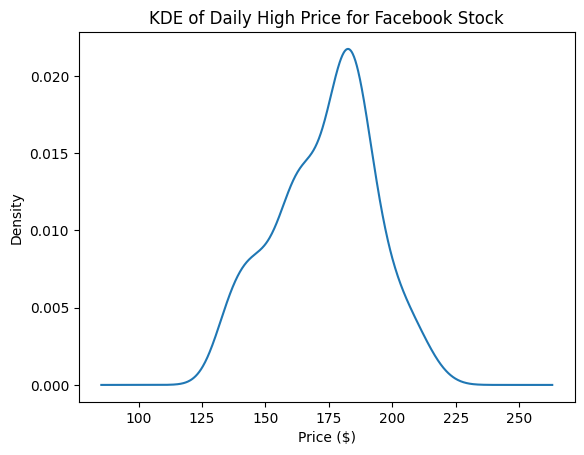

In [50]:
fb.high.plot(
    kind='kde',
    title='KDE of Daily High Price for Facebook Stock'
)
plt.xlabel('Price (\$)')

<>:8: SyntaxWarning: invalid escape sequence '\$'
<>:8: SyntaxWarning: invalid escape sequence '\$'
/var/folders/q7/1g4_b9fn3pd7z_qq7345v6vr0000gn/T/ipykernel_3663/1613113479.py:8: SyntaxWarning: invalid escape sequence '\$'
  plt.xlabel('Price (\$)')


Text(0.5, 0, 'Price (\\$)')

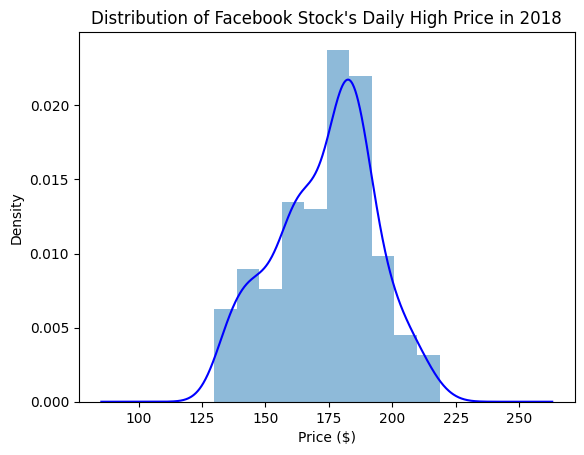

In [51]:
ax = fb.high.plot(kind='hist', density=True, alpha=0.5)
fb.high.plot(
    ax=ax,
    kind='kde',
    color='blue',
    title='Distribution of Facebook Stock\'s Daily High Price in 2018'
)
plt.xlabel('Price (\$)')

In [53]:
pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 2.7 MB/s eta 0:00:00 0:00:01

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Text(0.5, 1.0, 'ECDF of earthquake magnitude with magType ml')

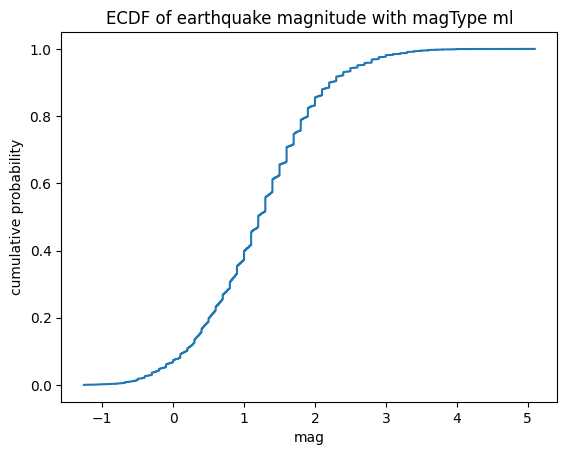

In [54]:
from statsmodels.distributions.empirical_distribution import ECDF

ecdf = ECDF(quakes.query('magType == "ml"').mag)
plt.plot(ecdf.x, ecdf.y)
plt.xlabel('mag')
plt.ylabel('cumulative probability')
plt.title('ECDF of earthquake magnitude with magType ml')

Text(0.5, 1.0, 'P(mag <= 3) = 98')

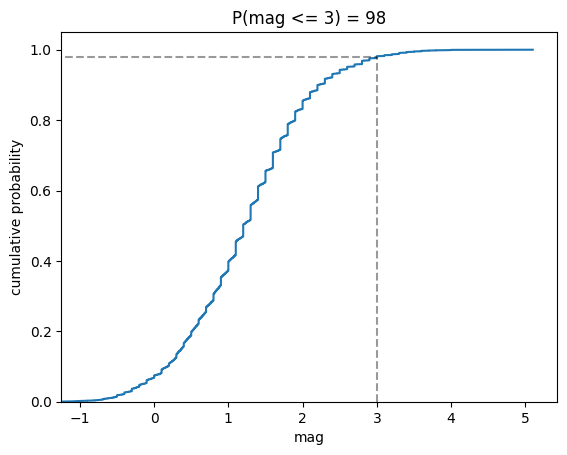

In [58]:
from statsmodels.distributions.empirical_distribution import ECDF

ecdf = ECDF(quakes.query('magType == "ml"').mag)
plt.plot(ecdf.x, ecdf.y)
plt.xlabel('mag')
plt.ylabel('cumulative probability')
plt.plot([3, 3], [0, .98], 'k--',
         [-1.5, 3], [0.98, 0.98], 'k--',
         alpha=0.4)
plt.ylim(0, None)
plt.xlim(-1.25, None)
plt.title('P(mag <= 3) = 98')

<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
/var/folders/q7/1g4_b9fn3pd7z_qq7345v6vr0000gn/T/ipykernel_3663/3861956816.py:2: SyntaxWarning: invalid escape sequence '\$'
  plt.ylabel('price (\$)')


Text(0, 0.5, 'price (\\$)')

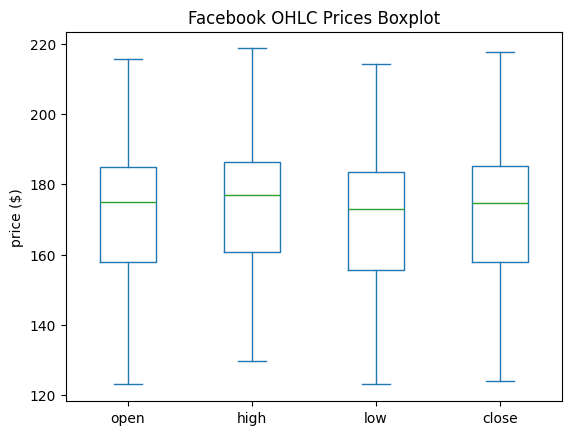

In [59]:
fb.iloc[:,:4].plot(kind='box', title='Facebook OHLC Prices Boxplot')
plt.ylabel('price (\$)')

Text(0.5, 1.1, 'Facebook OHLC Boxplots by Volume Traded')

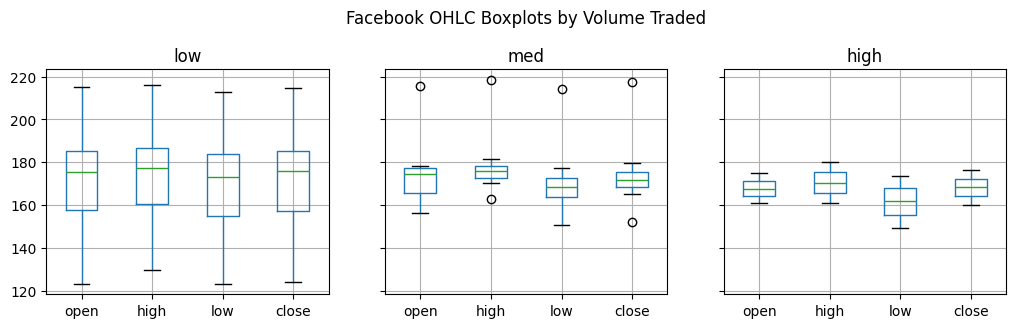

In [56]:
fb.assign(
    volume_bin=pd.cut(fb.volume, 3, labels=['low', 'med', 'high'])
).groupby('volume_bin').boxplot(
    column=['open', 'high', 'low', 'close'],
    layout=(1, 3),
    figsize=(12, 3)
)
plt.suptitle('Facebook OHLC Boxplots by Volume Traded', y=1.1)

Text(0, 0.5, 'magnitude')

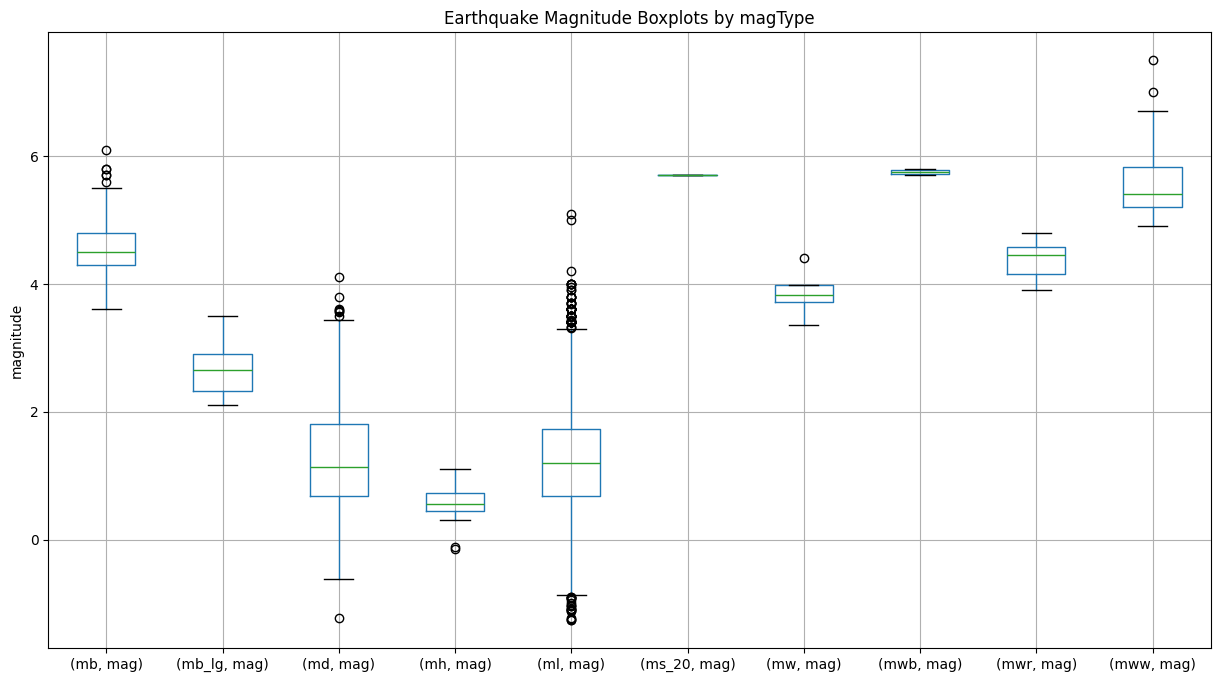

In [57]:
quakes[['mag', 'magType']].groupby('magType').boxplot(
    figsize=(15, 8),
    subplots=False
)
plt.title('Earthquake Magnitude Boxplots by magType')
plt.ylabel('magnitude')

Text(0, 0.5, 'Volume')

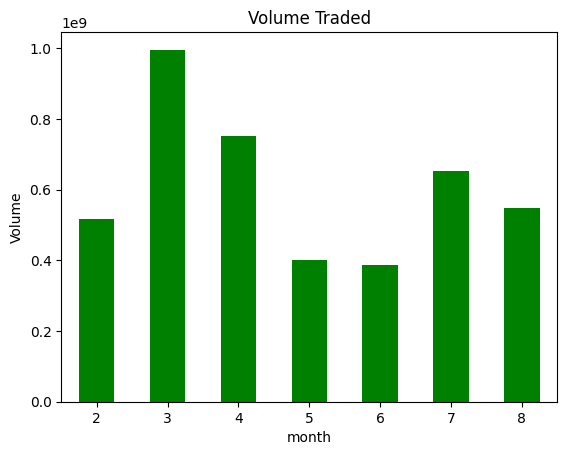

In [60]:
fb['2018-02':'2018-08'].assign(
    month=lambda x: x.index.month
).groupby('month').sum().volume.plot.bar(
    color='green', rot=0, title='Volume Traded'
)
plt.ylabel('Volume')

Text(0.5, 0, 'earthquakes')

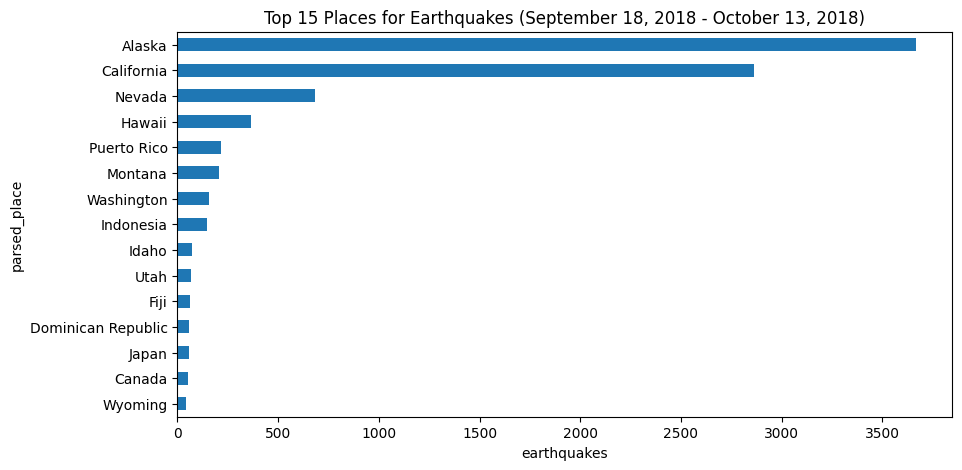

In [61]:
quakes.parsed_place.value_counts().iloc[14::-1].plot(
    kind='barh',
    figsize=(10, 5),
    title='Top 15 Places for Earthquakes (September 18, 2018 - October 13, 2018)'
)
plt.xlabel('earthquakes')

Text(0.5, 0, 'tsunamis')

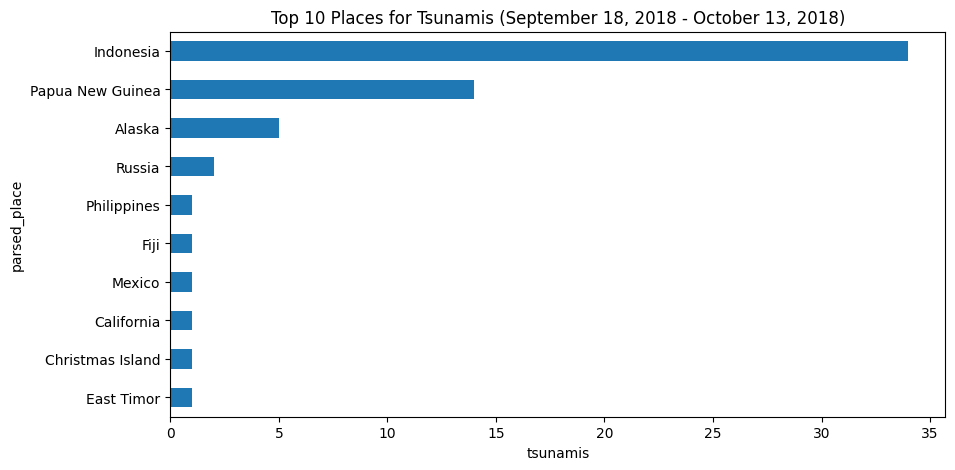

In [62]:
quakes.groupby('parsed_place').tsunami.sum().sort_values().iloc[-10:].plot(
    kind='barh',
    figsize=(10, 5),
    title='Top 10 Places for Tsunamis (September 18, 2018 - October 13, 2018)'
)
plt.xlabel('tsunamis')

Text(0, 0.5, 'count')

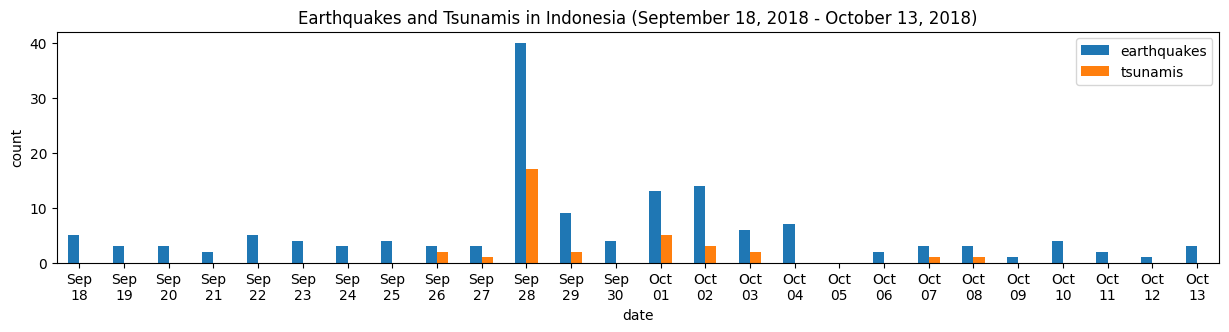

In [63]:
indonesia_quakes = quakes.query('parsed_place == "Indonesia"').assign(
    time=lambda x: pd.to_datetime(x.time, unit='ms'),
    earthquake=1
).set_index('time').resample('1D').sum()
indonesia_quakes.index = indonesia_quakes.index.strftime('%b\n%d')
indonesia_quakes.plot(
    y=['earthquake', 'tsunami'],
    kind='bar',
    figsize=(15, 3),
    rot=0,
    label=['earthquakes', 'tsunamis'],
    title='Earthquakes and Tsunamis in Indonesia (September 18, 2018 - October 13, 2018)'
)
plt.xlabel('date')
plt.ylabel('count')

Text(0, 0.5, 'earthquakes')

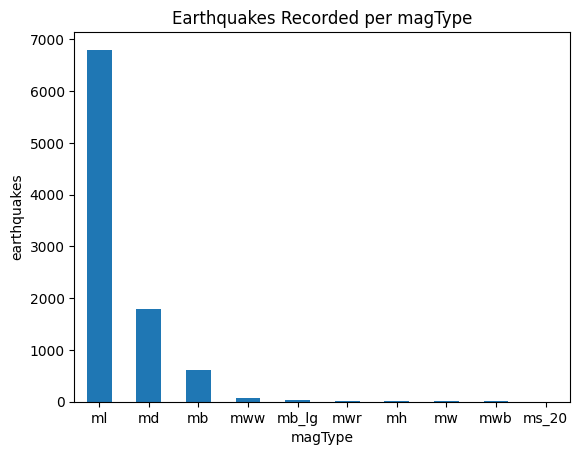

In [64]:
quakes.magType.value_counts().plot(
    kind='bar',
    title='Earthquakes Recorded per magType',
    rot=0
)
plt.xlabel('magType')
plt.ylabel('earthquakes')

Text(0, 0.5, 'earthquakes')

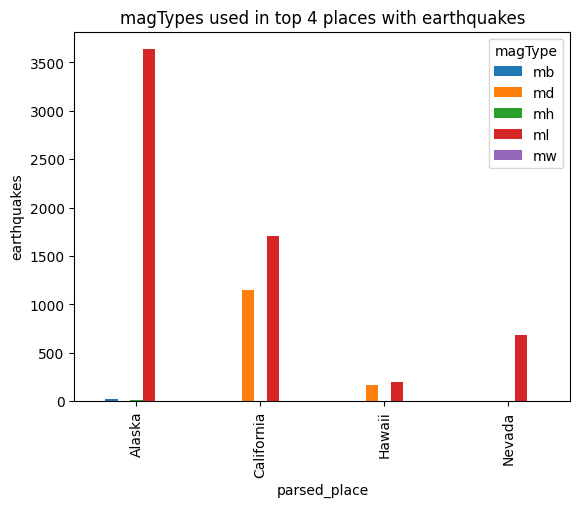

In [65]:
quakes[
    quakes.parsed_place.isin(['California', 'Alaska', 'Nevada', 'Hawaii'])
].groupby(['parsed_place', 'magType']).mag.count().unstack().plot.bar(
    title='magTypes used in top 4 places with earthquakes'
)
plt.ylabel('earthquakes')

Text(0, 0.5, 'earthquakes')

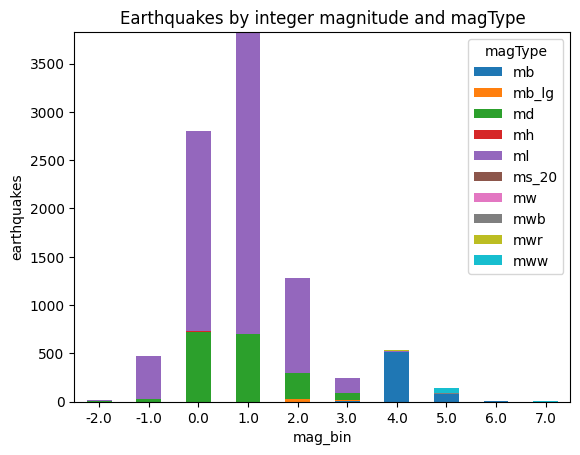

In [66]:
pivot = quakes.assign(
    mag_bin=lambda x: np.floor(x.mag)
).pivot_table(
    index='mag_bin',
    columns='magType',
    values='mag',
    aggfunc='count'
)
pivot.plot.bar(
    stacked=True,
    rot=0,
    title='Earthquakes by integer magnitude and magType'
)
plt.ylabel('earthquakes')

Text(0, 0.5, 'percentage')

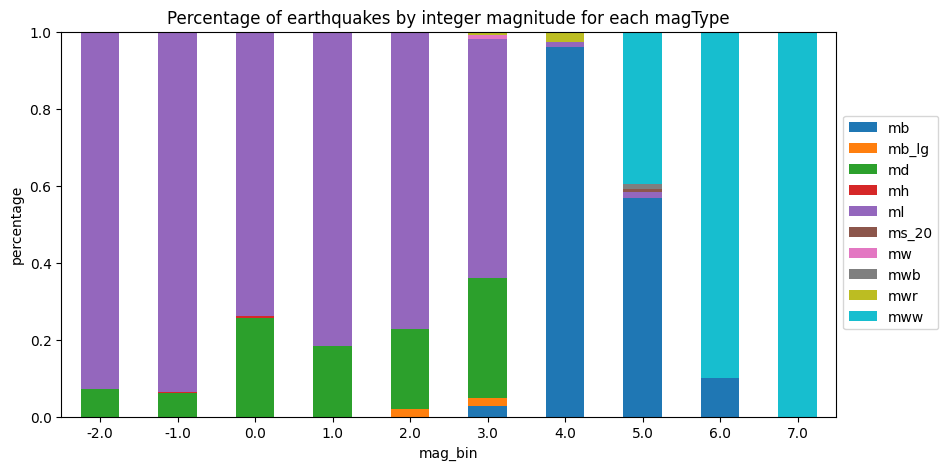

In [67]:
normalized_pivot = pivot.fillna(0).apply(lambda x: x / x.sum(), axis=1)
ax = normalized_pivot.plot.bar(
    stacked=True,
    rot=0,
    figsize=(10, 5),
    title='Percentage of earthquakes by integer magnitude for each magType'
)
ax.legend(bbox_to_anchor=(1, 0.8))
plt.ylabel('percentage')

## 9.3 Pandas Plotting Subpackage
Scatter matrix<br>
scatter_matrix from pandas.plotting creates a grid of scatter plots for every pair of columns. The diagonal can be histograms or KDE. It's a quick way to see relationships between many variables at once.

Lag plot<br>
A lag plot plots a variable against itself shifted by a certain number of days. For random data, the points look like a cloud. For stock prices, they line up along the diagonal – strong autocorrelation. We tried lag 1 and lag 5.

Autocorrelation plot<br>
autocorrelation_plot shows the correlation of a series with itself at different lags. The blue line is the correlation, and the shaded region shows what's probably just noise. Stock prices stayed above the noise for many lags, meaning past prices are related to future prices.

Bootstrap plot<br>
bootstrap_plot takes many random samples (with replacement) from the data and plots the distribution of the mean, median, and midrange. It gives you an idea of how stable those statistics are. For Facebook volume, the mean was around 25 million, and the bootstrap samples showed some variation around that.

In [69]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fb = pd.read_csv(
    '/Users/macbookpro/CPE-311/HOA/HOA 9.1/Datasets/fb_stock_prices_2018.csv',
    index_col='date', parse_dates=True
)

array([[<Axes: xlabel='open', ylabel='open'>,
        <Axes: xlabel='high', ylabel='open'>,
        <Axes: xlabel='low', ylabel='open'>,
        <Axes: xlabel='close', ylabel='open'>,
        <Axes: xlabel='volume', ylabel='open'>],
       [<Axes: xlabel='open', ylabel='high'>,
        <Axes: xlabel='high', ylabel='high'>,
        <Axes: xlabel='low', ylabel='high'>,
        <Axes: xlabel='close', ylabel='high'>,
        <Axes: xlabel='volume', ylabel='high'>],
       [<Axes: xlabel='open', ylabel='low'>,
        <Axes: xlabel='high', ylabel='low'>,
        <Axes: xlabel='low', ylabel='low'>,
        <Axes: xlabel='close', ylabel='low'>,
        <Axes: xlabel='volume', ylabel='low'>],
       [<Axes: xlabel='open', ylabel='close'>,
        <Axes: xlabel='high', ylabel='close'>,
        <Axes: xlabel='low', ylabel='close'>,
        <Axes: xlabel='close', ylabel='close'>,
        <Axes: xlabel='volume', ylabel='close'>],
       [<Axes: xlabel='open', ylabel='volume'>,
        <Axes: xlabe

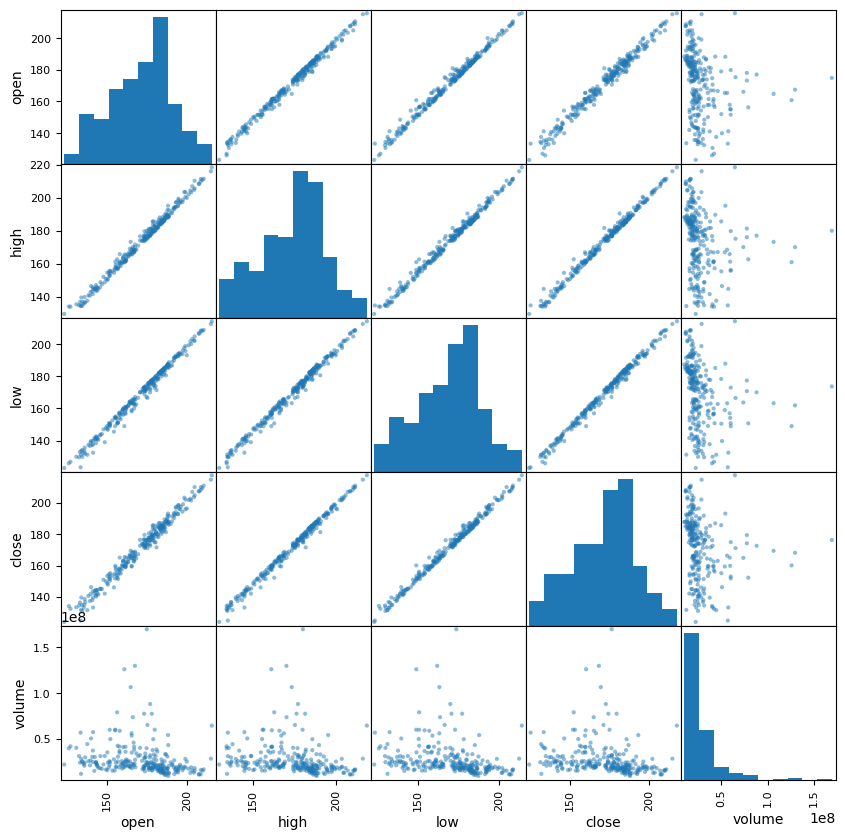

In [70]:
from pandas.plotting import scatter_matrix
scatter_matrix(fb, figsize=(10, 10))

array([[<Axes: xlabel='open', ylabel='open'>,
        <Axes: xlabel='high', ylabel='open'>,
        <Axes: xlabel='low', ylabel='open'>,
        <Axes: xlabel='close', ylabel='open'>,
        <Axes: xlabel='volume', ylabel='open'>],
       [<Axes: xlabel='open', ylabel='high'>,
        <Axes: xlabel='high', ylabel='high'>,
        <Axes: xlabel='low', ylabel='high'>,
        <Axes: xlabel='close', ylabel='high'>,
        <Axes: xlabel='volume', ylabel='high'>],
       [<Axes: xlabel='open', ylabel='low'>,
        <Axes: xlabel='high', ylabel='low'>,
        <Axes: xlabel='low', ylabel='low'>,
        <Axes: xlabel='close', ylabel='low'>,
        <Axes: xlabel='volume', ylabel='low'>],
       [<Axes: xlabel='open', ylabel='close'>,
        <Axes: xlabel='high', ylabel='close'>,
        <Axes: xlabel='low', ylabel='close'>,
        <Axes: xlabel='close', ylabel='close'>,
        <Axes: xlabel='volume', ylabel='close'>],
       [<Axes: xlabel='open', ylabel='volume'>,
        <Axes: xlabe

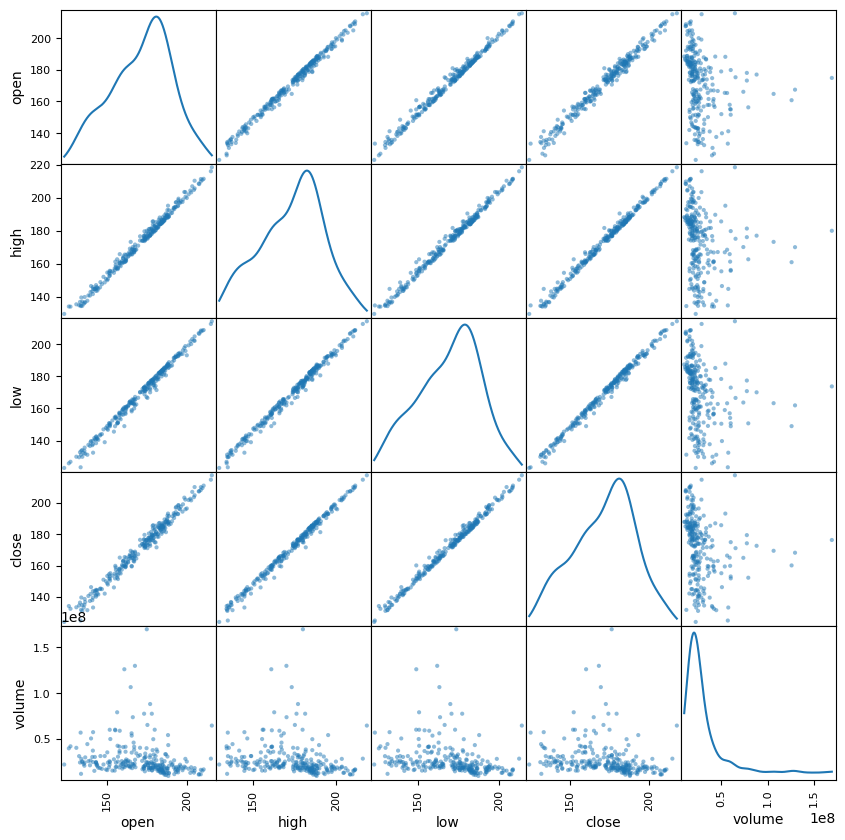

In [71]:
scatter_matrix(fb, figsize=(10, 10), diagonal='kde')

<Axes: xlabel='y(t)', ylabel='y(t + 1)'>

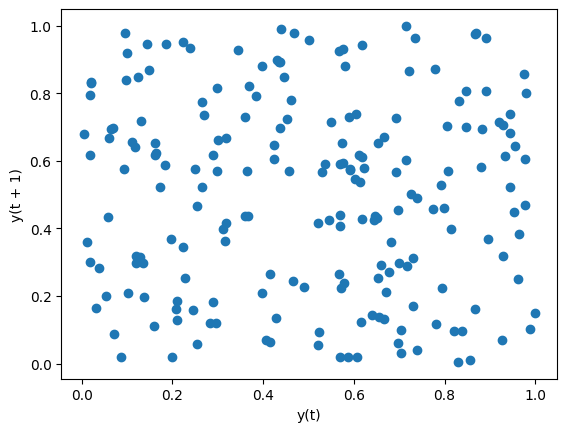

In [72]:
from pandas.plotting import lag_plot
np.random.seed(0) # make this repeatable
lag_plot(pd.Series(np.random.random(size=200)))

<Axes: xlabel='y(t)', ylabel='y(t + 1)'>

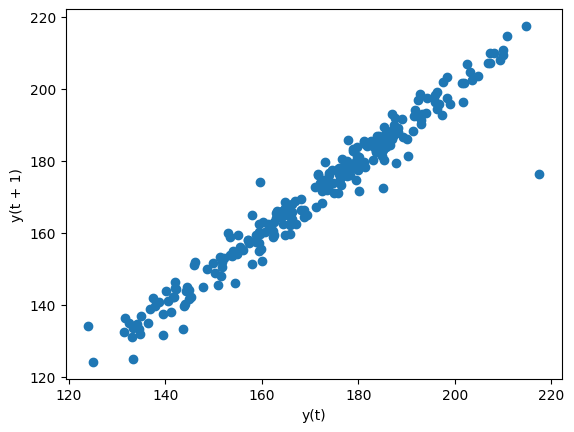

In [73]:
lag_plot(fb.close)

<Axes: xlabel='y(t)', ylabel='y(t + 5)'>

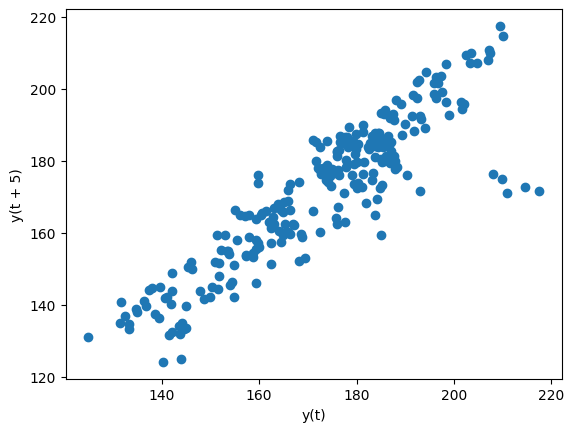

In [74]:
lag_plot(fb.close, lag=5)

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

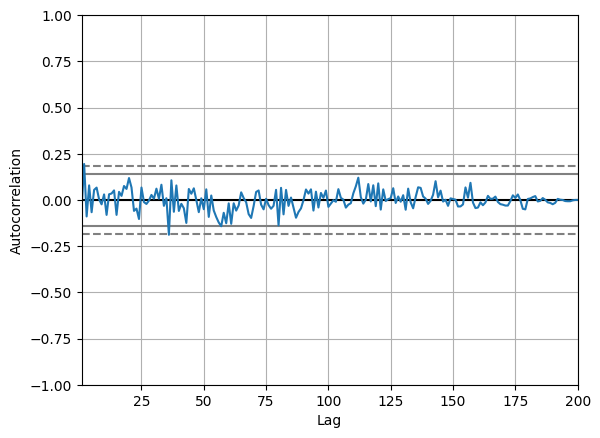

In [75]:
from pandas.plotting import autocorrelation_plot
np.random.seed(0) # make this repeatable
autocorrelation_plot(pd.Series(np.random.random(size=200)))

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

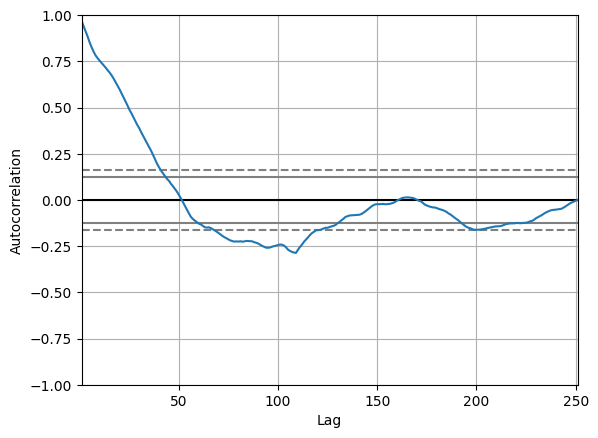

In [76]:
autocorrelation_plot(fb.close)

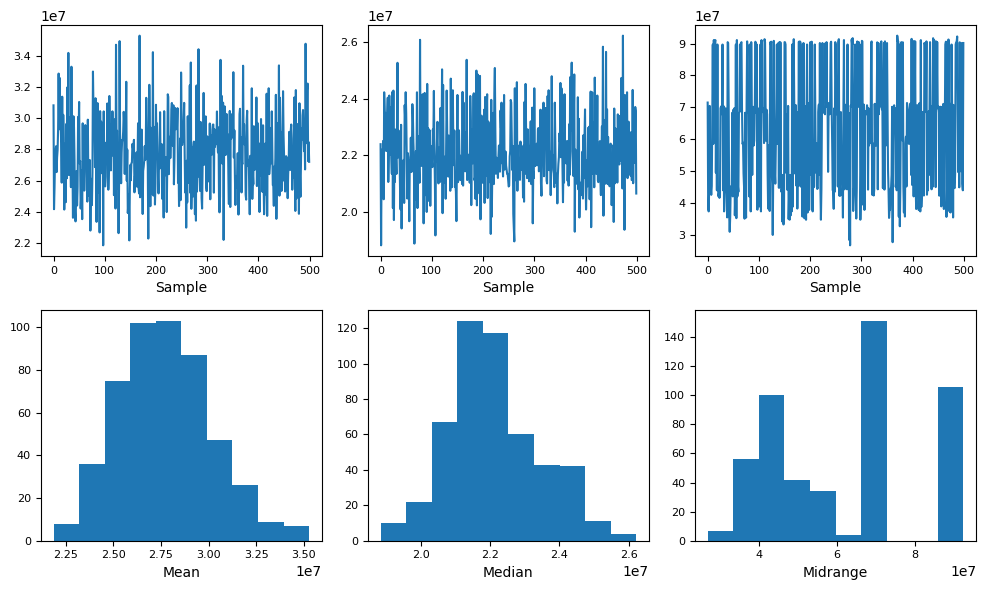

In [77]:
from pandas.plotting import bootstrap_plot
fig = bootstrap_plot(fb.volume, fig=plt.figure(figsize=(10, 6)))